# 01 — Explore ECOSoundSet
Inspect the dataset, understand class distribution, and identify which UK Orthoptera species have sufficient clips.

**Kernel:** `Python (orthoptera-training)`  
**Dataset:** `datasets/ecosoundset/` — download via `zenodo_get 15043892` if not present.

In [21]:
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent  # cwd relative to current notebook path
ECO_ROOT = PROJECT_ROOT / "datasets" / "ecosoundset"
INSECT_ROOT = PROJECT_ROOT / "datasets" / "insectset459"


## EcoSoundSet Exploration

In [28]:
# ── Load annotations and filter to train split ────────────────────────────────
all_annot_eco = pd.read_csv(ECO_ROOT / "annotated_audio_segments.csv")
train = all_annot_eco[all_annot_eco["subset"] == "train"].copy()
print(f"Total clips: {all_annot_eco['audio_segment_file_name'].nunique()}")
print(f"Total annotations (train): {len(train)}")
print(f"Columns: {list(train.columns)}")
train.head()


Total clips: 41883
Total annotations (train): 66903
Columns: ['recording_id', 'audio_segment_initial_time', 'audio_segment_final_time', 'annotation_initial_time', 'annotation_final_time', 'annotation_min_freq', 'annotation_max_freq', 'label', 'label_category', 'subset', 'audio_segment_file_name']


,recording_id,audio_segment_initial_time,audio_segment_final_time,annotation_initial_time,annotation_final_time,annotation_min_freq,annotation_max_freq,label,label_category,subset,audio_segment_file_name
0,43,0,4,0.000000,4.000000,3248.110352,4453.847656,Eumodicogryllus bordigalensis bordigalensis,Orthoptera,train,FocalRecording_LaPe_01VII2022_43_split_0_4.wav
1,43,0,4,0.355751,4.000000,0.000000,375.226135,Wind,Geophony,train,FocalRecording_LaPe_01VII2022_43_split_0_4.wav
2,43,0,4,0.792816,4.000000,1165.831787,2618.664307,Alytes obstetricans,Anura,train,FocalRecording_LaPe_01VII2022_43_split_0_4.wav
3,43,4,8,4.000000,4.147038,0.000000,375.226135,Wind,Geophony,train,FocalRecording_LaPe_01VII2022_43_split_4_8.wav
4,43,4,8,5.346426,6.708443,0.000000,375.226135,Wind,Geophony,train,FocalRecording_LaPe_01VII2022_43_split_4_8.wav


In [3]:
# ── Quantify Overlapping Annotations ──────────────────────────────────────────
labels_per_file = all_annot_eco.groupby("audio_segment_file_name")["label"].count()
print(f"{'Clips with overlapping annotations:':<35} {labels_per_file[labels_per_file > 1].count()}")
print(f"{'Average annotations per file:':<35} {labels_per_file.mean()}")
print(f"{'Least annotations per file:':<35} {labels_per_file.min()}")
print(f"{'Least annotated file:':<35} {labels_per_file.idxmin()}")
print(f"{'Maximum annotations per file:':<35} {labels_per_file.max()}")
print(f"{'Most annotated file:':<35} {labels_per_file.idxmax()}")


Clips with overlapping annotations: 23157
Average annotations per file:       2.6601962610128216
Least annotations per file:         1
Least annotated file:               FocalRecording_AdCh_03VIII2021_33405_split_0_4.wav
Maximum annotations per file:       357
Most annotated file:                Soundscape_BlCa_20VIII2015_27451_split_0_4.wav


In [4]:
# ── All Orthoptera species in the train split ────────────────────────────────
orth_eco = train[train["label_category"] == "Orthoptera"]
print(f"Orthoptera species: {orth_eco['label'].nunique()}\n")
print(f"Annotations per species:\n\n{orth_eco['label'].value_counts().to_string()}")


Orthoptera species: 120

Annotations per species:

label
Tettigonia viridissima                         5897
Gryllus campestris                             3184
Ruspolia nitidula nitidula                     2168
Roeseliana roeselii                            2148
Pholidoptera griseoaptera                      1829
Isophya kraussii                               1444
Eumodicogryllus bordigalensis bordigalensis    1437
Oecanthus pellucens pellucens                  1258
Pseudochorthippus parallelus parallelus        1244
Conocephalus fuscus                            1162
Platycleis albopunctata albopunctata            999
Leptophyes punctatissima                        997
Tettigonia cantans                              811
Bicolorana bicolor bicolor                      762
Ephippiger diurnus diurnus                      732
Phaneroptera nana                               639
Nemobius sylvestris sylvestris                  620
Chorthippus biguttulus biguttulus               572
Phanero

In [30]:
# ── Filter to UK target species ───────────────────────────────────────────────
# ECOSoundSet uses trinomial names; Meconema thalassinum is absent from both datasets.
UK_SPECIES = [
    "Chorthippus brunneus brunneus",           # Field Grasshopper
    "Pseudochorthippus parallelus parallelus", # Meadow Grasshopper
    "Omocestus viridulus",                     # Common Green Grasshopper
    "Tettigonia viridissima",                  # Great Green Bush-cricket
    "Roeseliana roeselii",                     # Roesel's Bush-cricket
    "Pholidoptera griseoaptera",               # Dark Bush-cricket
    "Leptophyes punctatissima",                # Speckled Bush-cricket
    "Gryllus campestris",                      # Field Cricket
]

orth_uk_eco = orth_eco[orth_eco["label"].isin(UK_SPECIES)].copy()
# Multiple annotations can appear per clips. Annotation count does not equal clip count.
print(f"ECOSoundSet UK species annotations: {len(orth_uk_eco)}")
print(f"ECOSoundSet UK species clips: {orth_uk_eco['audio_segment_file_name'].nunique()}")
labels_per_file_orth = orth_uk_eco.groupby("audio_segment_file_name")["label"].count()
print(f"{'Average annotations per file:':<30} {labels_per_file_orth.mean()}")
print(f"\nAnnotations per species:\n\n{orth_uk_eco['label'].value_counts().to_string()}")


ECOSoundSet UK species annotations: 15621
ECOSoundSet UK species clips: 9611
Average annotations per file:  1.62532514826761

Annotations per species:

label
Tettigonia viridissima                     5897
Gryllus campestris                         3184
Roeseliana roeselii                        2148
Pholidoptera griseoaptera                  1829
Pseudochorthippus parallelus parallelus    1244
Leptophyes punctatissima                    997
Chorthippus brunneus brunneus               179
Omocestus viridulus                         143


In [6]:
# ── Quantify overlapping Orthoptera annotations ───────────────────────────────
# Files with at least one UK target species annotation.
uk_files = set(orth_uk_eco["audio_segment_file_name"])

# Files with at least 2 distinct Orthoptera annotations.
multi_orth = all_annot_eco[all_annot_eco["label_category"] == "Orthoptera"].groupby("audio_segment_file_name")["label"].nunique()
multi_orth_files = multi_orth[multi_orth > 1].index

# Files in both.
mixed_files = uk_files.intersection(multi_orth_files)

print(f"{'Clips with distinct overlapping Orthoptera annotations:'} {len(mixed_files)}")


Clips with distinct overlapping Orthoptera annotations: 3950


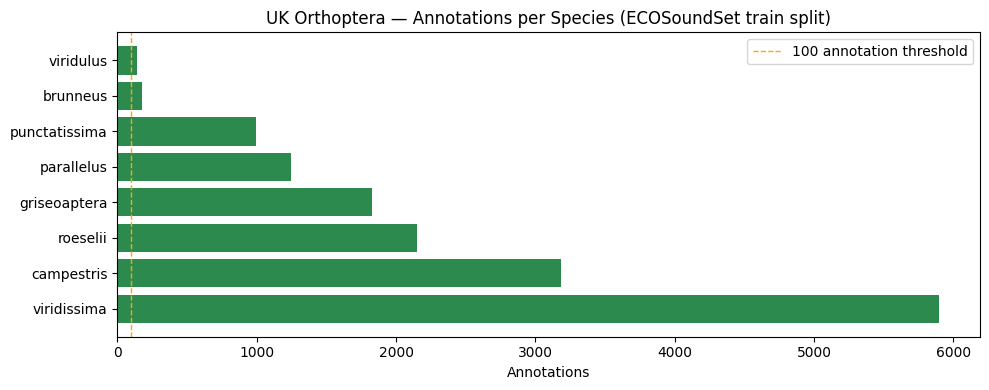

In [7]:
# ── Visualise class balance ───────────────────────────────────────────────────
counts = orth_uk_eco["label"].value_counts()
short_names = [s.split()[-1] for s in counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(short_names, counts.values, color="#2d8a4e")
ax.set_xlabel("Annotations")
ax.set_title("UK Orthoptera — Annotations per Species (ECOSoundSet train split)")
ax.axvline(100, color="orange", linestyle="--", linewidth=1, label="100 annotation threshold")
ax.legend()
plt.tight_layout()
plt.show()

low = counts[counts < 50]
if len(low):
    print(f"\n⚠ Species with <50 annotations (consider InsectSet459 supplement):")
    print(low.to_string())


In [8]:
# ── Illuminate avg, min, and max range of frequencies across Orthoptera annotations ─────
freq_avg_eco = orth_uk_eco.groupby("label")[["annotation_min_freq", "annotation_max_freq"]].mean()
print(f"{freq_avg_eco.to_string()}\n")

freq_min_eco = orth_uk_eco.groupby("label")["annotation_min_freq"].agg(["min", "idxmin"])
freq_min_eco.rename(columns={"min": "Minimum Frequency", "idxmin": "Row Index"}, inplace=True)
print(f"{freq_min_eco}\n")

freq_max_eco = orth_uk_eco.groupby("label")["annotation_max_freq"].agg(["max", "idxmax"])
freq_max_eco.rename(columns={"max": "Maximum Frequency", "idxmax": "Row Index"}, inplace=True)
print(freq_max_eco)


                                         annotation_min_freq  annotation_max_freq
label                                                                            
Chorthippus brunneus brunneus                    6313.191633         29306.149801
Gryllus campestris                               3740.130144          6645.931931
Leptophyes punctatissima                        25912.309263         47816.168193
Omocestus viridulus                              4235.488792         21503.505702
Pholidoptera griseoaptera                        8327.743876         43955.869186
Pseudochorthippus parallelus parallelus          6448.285842         35407.325796
Roeseliana roeselii                             10972.394016         36515.688866
Tettigonia viridissima                           3711.678758         21188.221947

                                         Minimum Frequency  Row Index
label                                                                
Chorthippus brunneus brunneus          

Species:            Voice
File:               FocalRecording_LaPe_26VIII2022_1599_split_16_20.wav
Annotation Start:   16.0
Annotation End:     16.355415
Sample Rate:        96000 Hz
Duration:           0.4 s


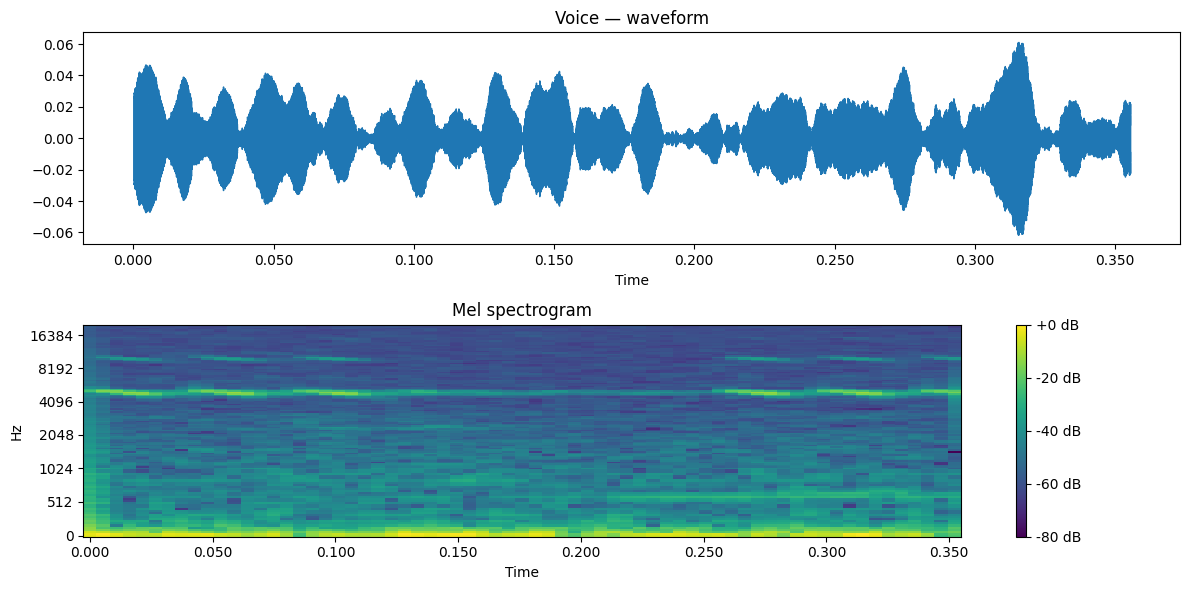

In [9]:
# ── Inspect a clip — spectrogram preview ─────────────────────────────────────
# Set use_random to True for a randomised UK Orthoptera sample
# Set use_random to False to select any annotation from ECOSoundSet
use_random = False
selected_index = 12412  # CSV row number minus 1

if use_random:
    sample = orth_uk_eco.sample(1).iloc[0]
else:
    sample = all_annot_eco.loc[selected_index]

audio_path = next(ECO_ROOT.rglob(sample["audio_segment_file_name"]), None)

if audio_path and audio_path.exists():
    t_start = sample["annotation_initial_time"] - sample["audio_segment_initial_time"]
    t_end = sample["annotation_final_time"] - sample["annotation_initial_time"]
    y, sample_rate = librosa.load(audio_path, sr=None, offset=t_start, duration=t_end - t_start)
    print(f"{'Species:':<20}{sample['label']}")
    print(f"{'File:':<20}{sample['audio_segment_file_name']}")
    print(f"{'Annotation Start:':<20}{sample['annotation_initial_time']}")
    print(f"{'Annotation End:':<20}{sample['annotation_final_time']}")
    print(f"{'Sample Rate:':<20}{sample_rate} Hz")
    print(f"{'Duration:':<20}{sample['annotation_final_time'] - sample['annotation_initial_time']:.1f} s")

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    librosa.display.waveshow(y, sr=sample_rate, ax=axes[0])
    axes[0].set_title(f"{sample['label']} — waveform")

    n_fft = min(2048, len(y))
    S = librosa.feature.melspectrogram(y=y, sr=sample_rate, n_mels=128, fmax=20000, n_fft=n_fft)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sample_rate, x_axis="time", y_axis="mel",
                             fmax=20000, ax=axes[1], cmap="viridis")
    axes[1].set_title("Mel spectrogram")
    plt.colorbar(axes[1].collections[0], ax=axes[1], format="%+2.0f dB")
    plt.tight_layout()
    plt.show()
else:
    print(f"Audio file not found: {audio_path}")


## InsectSet459 Exploration

In [10]:
# ── Load annotations and filter to train split ────────────────────────────────
all_annot_insect = pd.read_csv(INSECT_ROOT / "InsectSet459_Train_Val_Annotation.csv")
# Use train and validation subset as training data, use ECO val and test as definitive evaluation sets.
print(f"Total clips: {all_annot_insect['file_name'].nunique()}")
print(f"Total annotations (train and validation): {len(all_annot_insect)}")
print(f"Columns: {list(all_annot_insect.columns)}")
print(all_annot_insect["background"].unique())
all_annot_insect.head()


Total clips: 21180
Total annotations (train and validation): 21180
Columns: ['file_name', 'species_name', 'group', 'license', 'contributor', 'observation', 'file', 'background', 'original_name', 'subset']
<StringArray>
[                                                                                                                nan,
                                                                                                 'Fringilla coelebs',
                                                                                                       'Parus major',
                                                                                                'Chorthippus vagans',
                                          'Fringilla coelebs, Sylvia atricapilla, Turdus merula, Erithacus rubecula',
                                                                                                   'Cuculus canorus',
 'Cuculus canorus, Turdus philomelos, Oriolus oriolus, Emberiza citrinell

,file_name,species_name,group,license,contributor,observation,file,background,original_name,subset
0,Eunemobius_carolinus_IN435132_563.mp3,Eunemobius_carolinus,Orthoptera,http://creativecommons.org/publicdomain/zero/1.0/,Kent McFarland,https://www.inaturalist.org/observations/435132,https://static.inaturalist.org/sounds/563.mp3?...,NaN,Eunemobius_carolinus,Train
1,Tettigonia_viridissima_IN229082203_1131087.mp3,Tettigonia_viridissima,Orthoptera,http://creativecommons.org/publicdomain/zero/1.0/,ahabo,https://www.inaturalist.org/observations/22908...,https://static.inaturalist.org/sounds/1131087....,NaN,Tettigonia_viridissima,Train
2,Oecanthus_dulcisonans_IN232353068_1146352.mp3,Oecanthus_dulcisonans,Orthoptera,http://creativecommons.org/licenses/by-nc/4.0/,mathieu_pelissie,https://www.inaturalist.org/observations/23235...,https://static.inaturalist.org/sounds/1146352....,NaN,Oecanthus_dulcisonans,Validation
3,Eumodicogryllus_bordigalensis_IN231583058_1142...,Eumodicogryllus_bordigalensis,Orthoptera,http://creativecommons.org/licenses/by-nc/4.0/,Tomáš Dvořák,https://www.inaturalist.org/observations/23158...,https://static.inaturalist.org/sounds/1142992....,NaN,Eumodicogryllus_bordigalensis,Validation
4,Oecanthus_pellucens_IN231470435_1142536.mp3,Oecanthus_pellucens,Orthoptera,http://creativecommons.org/licenses/by-nc/4.0/,brigospo,https://www.inaturalist.org/observations/23147...,https://static.inaturalist.org/sounds/1142536....,NaN,Oecanthus_pellucens,Validation


In [11]:
# ── Detect overlapping annotations (details no overlapping annotations unlike ECO) ──────
labels_per_file_insect = all_annot_insect.groupby("file_name")["species_name"].count()
print(f"{'Average annotations per file:':<30} {labels_per_file_insect.mean()}")
print(f"{'Least annotations per file:':<30} {labels_per_file_insect.min()}")
print(f"{'Least annotated file:':<30} {labels_per_file_insect.idxmin()}")
print(f"{'Maximum annotations per file:':<30} {labels_per_file_insect.max()}")
print(f"{'Most annotated file:':<30} {labels_per_file_insect.idxmax()}")


Average annotations per file:  1.0
Least annotations per file:    1
Least annotated file:          Acanthoventris_drewseni_IN105268482_348002.mp3
Maximum annotations per file:  1
Most annotated file:           Acanthoventris_drewseni_IN105268482_348002.mp3


In [12]:
# ── Quantify Orthoptera annotations in the dataset ────────────────────────────────
orth_insect = all_annot_insect[all_annot_insect["group"] == "Orthoptera"]
print(f"Orthoptera species: {orth_insect['species_name'].nunique()}\n")
print(f"Annotations per species:\n\n{orth_insect['species_name'].value_counts().to_string()}")


Orthoptera species: 310

Annotations per species:

species_name
Pterophylla_camellifolia         718
Gryllus_campestris               540
Tettigonia_viridissima           497
Oecanthus_pellucens              394
Chorthippus_biguttulus           268
Roeseliana_roeselii              233
Pholidoptera_griseoaptera        227
Tettigonia_cantans               211
Pseudochorthippus_parallelus     181
Chorthippus_brunneus             164
Eumodicogryllus_bordigalensis    159
Decticus_albifrons               146
Gryllus_bimaculatus              144
Chorthippus_mollis               142
Gryllus_pennsylvanicus           141
Microcentrum_rhombifolium        133
Conocephalus_fuscus              123
Phaneroptera_nana                116
Gryllotalpa_gryllotalpa          114
Platycleis_albopunctata          111
Leptophyes_punctatissima         106
Oecanthus_dulcisonans            102
Ruspolia_nitidula                 95
Phaneroptera_falcata              94
Nemobius_sylvestris               92
Neoconoceph

In [31]:
UK_SPECIES_INSECT = [
    "Chorthippus_brunneus",
    "Pseudochorthippus_parallelus",
    "Omocestus_viridulus",
    "Tettigonia_viridissima",
    "Roeseliana_roeselii",
    "Pholidoptera_griseoaptera",
    "Leptophyes_punctatissima",
    "Gryllus_campestris"
]

orth_uk_insect = orth_insect[orth_insect["species_name"].isin(UK_SPECIES_INSECT)].copy()
print(f"InsectSet459 UK species annotations: {len(orth_uk_insect)}")
print(f"InsectSet459 UK species clips: {orth_uk_insect['file_name'].nunique()}")
print(f"\nAnnotations per species:\n\n{orth_uk_insect['species_name'].value_counts().to_string()}\n")

insect_file_index = {f.name: f for f in INSECT_ROOT.rglob("*") if f.suffix in (".wav", ".mp3")}
orth_uk_insect["filepath"] = orth_uk_insect["file_name"].map(insect_file_index)
print(f"Max clip duration: {orth_uk_insect['filepath'].apply(lambda fp: sf.info(fp).duration).max()}")
print(f"Minimum clip duration: {orth_uk_insect['filepath'].apply(lambda fp: sf.info(fp).duration).min()}")
print(f"Average clip duration: {orth_uk_insect['filepath'].apply(lambda fp: sf.info(fp).duration).mean()}")


InsectSet459 UK species annotations: 2018
InsectSet459 UK species clips: 2018

Annotations per species:

species_name
Gryllus_campestris              540
Tettigonia_viridissima          497
Roeseliana_roeselii             233
Pholidoptera_griseoaptera       227
Pseudochorthippus_parallelus    181
Chorthippus_brunneus            164
Leptophyes_punctatissima        106
Omocestus_viridulus              70

Max clip duration: 120.064
Minimum clip duration: 0.896
Average clip duration: 28.54525078335719


In [ ]:
# ── Inspect a clip — spectrogram preview ─────────────────────────────────────
# Set use_random to True for a randomised UK Orthoptera sample
# Set use_random to False to select any annotation from InsectSet459
use_random = False
selected_index = 11  # CSV row number minus 1

if use_random:
    sample = orth_uk_insect.sample(1).iloc[0]
else:
    sample = all_annot_insect.loc[selected_index]

audio_path_insect = next(INSECT_ROOT.rglob(sample["file_name"]), None)

if audio_path_insect and audio_path_insect.exists():
    y, sample_rate = librosa.load(audio_path_insect, sr=None)
    print(f"{'Species:':<20}{sample['species_name']}")
    print(f"{'File:':<20}{sample['file_name']}")
    print(f"{'Sample Rate:':<20}{sample_rate} Hz")
    print(f"Sample rate: {sample_rate} Hz   Duration: {len(y) / sample_rate:.1f} s")

    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    librosa.display.waveshow(y, sr=sample_rate, ax=axes[0])
    axes[0].set_title(f"{sample['species_name']} — waveform")

    n_fft = min(2048, len(y))
    S = librosa.feature.melspectrogram(y=y, sr=sample_rate, n_mels=128, fmax=20000, n_fft=n_fft)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sample_rate, x_axis="time", y_axis="mel",
                             fmax=20000, ax=axes[1], cmap="viridis")
    axes[1].set_title("Mel spectrogram")
    plt.colorbar(axes[1].collections[0], ax=axes[1], format="%+2.0f dB")
    plt.tight_layout()
    plt.show()
else:
    print(f"Audio file not found: {audio_path}")
    